In [4]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("tf.Keras version:", tf.keras.__version__)

TensorFlow version: 2.21.0
tf.Keras version: 3.14.1


UPLOAD GAMBAR


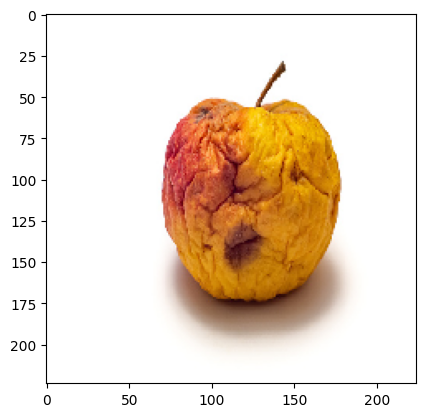

File Output : apelbusukjir.jpg
Prediksi    : Rotten Apples
Confidence  : 99.63%


In [7]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog

# label dataset
IMG_SIZE = (224, 224)
LABELS = [
    'Fresh Apples',
    'Fresh Banana',
    'Fresh Oranges',
    'Rotten Apples',
    'Rotten Banana',
    'Rotten Oranges'
]

model_path = 'mobilenet_fruit_model.keras'
model = tf.keras.models.load_model(model_path, compile=False)

def predict_local_image():
    print("UPLOAD GAMBAR")
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    file_path = filedialog.askopenfilename(
        title="Pilih Gambar Buah",
        filetypes=[("Image files", "*.jpg *.jpeg *.png")]
    )
    if not file_path:
        print("closed")
        return

    filename = os.path.basename(file_path)

    # load and resize gambar
    img = image.load_img(file_path, target_size=IMG_SIZE)

    plt.imshow(img)
    plt.show()

    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    # proses inferensi
    classes = model.predict(x, verbose=0)
    result_idx = np.argmax(classes[0])
    confidence = classes[0][result_idx] * 100

    # tampilkan hasil
    print(f"File Output : {filename}")
    print(f"Prediksi    : {LABELS[result_idx]}")
    print(f"Confidence  : {confidence:.2f}%")

if __name__ == "__main__":
    predict_local_image()

In [2]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image

# load model
MODEL_PATH = 'mobilenet_fruit_model.keras' 
print("memuat model")
model = tf.keras.models.load_model(MODEL_PATH)

LABELS = ['Fresh Apples', 'Fresh Banana', 'Fresh Oranges', 
          'Rotten Apples', 'Rotten Banana', 'Rotten Oranges']
IMG_SIZE = (224, 224)

# use webcam
cap = cv2.VideoCapture(0)

print("kamera menyala. klik 'q' di keyboard untuk keluar")

while True:
    # frame reading
    ret, frame = cap.read()
    if not ret:
        print("[ERROR]")
        break

    # ubah format bgr ke rgb
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # ubah ukuran sesuai input
    img_resized = cv2.resize(rgb_frame, IMG_SIZE)
    
    x = image.img_to_array(img_resized)
    x = np.expand_dims(x, axis=0)

    classes = model.predict(x, verbose=0)
    result_idx = np.argmax(classes[0])
    confidence = classes[0][result_idx] * 100

    # teks untuk ditampilkan
    label_text = f"{LABELS[result_idx]} ({confidence:.2f}%)"

    # teks pojok atas
    cv2.putText(frame, label_text, (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 
                1, (0, 255, 0), 2, cv2.LINE_AA)
    
    # preview gambar
    cv2.imshow('Live Fruit Detection', frame)

    # function untuk keluar
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

memuat model
kamera menyala. klik 'q' di keyboard untuk keluar
